In [1]:
import pandas as pd

survey = pd.read_csv("masculinity.csv")
print(survey.columns)

Index(['Unnamed: 0', 'StartDate', 'EndDate', 'q0001', 'q0002', 'q0004_0001',
       'q0004_0002', 'q0004_0003', 'q0004_0004', 'q0004_0005', 'q0004_0006',
       'q0005', 'q0007_0001', 'q0007_0002', 'q0007_0003', 'q0007_0004',
       'q0007_0005', 'q0007_0006', 'q0007_0007', 'q0007_0008', 'q0007_0009',
       'q0007_0010', 'q0007_0011', 'q0008_0001', 'q0008_0002', 'q0008_0003',
       'q0008_0004', 'q0008_0005', 'q0008_0006', 'q0008_0007', 'q0008_0008',
       'q0008_0009', 'q0008_0010', 'q0008_0011', 'q0008_0012', 'q0009',
       'q0010_0001', 'q0010_0002', 'q0010_0003', 'q0010_0004', 'q0010_0005',
       'q0010_0006', 'q0010_0007', 'q0010_0008', 'q0011_0001', 'q0011_0002',
       'q0011_0003', 'q0011_0004', 'q0011_0005', 'q0012_0001', 'q0012_0002',
       'q0012_0003', 'q0012_0004', 'q0012_0005', 'q0012_0006', 'q0012_0007',
       'q0013', 'q0014', 'q0015', 'q0017', 'q0018', 'q0019_0001', 'q0019_0002',
       'q0019_0003', 'q0019_0004', 'q0019_0005', 'q0019_0006', 'q0019_0007',
      

In [2]:
cols_to_map = ["q0007_0001", "q0007_0002", "q0007_0003", "q0007_0004",
       "q0007_0005", "q0007_0006", "q0007_0007", "q0007_0008", "q0007_0009",
       "q0007_0010", "q0007_0011"]
for column in cols_to_map:
    survey[column] = survey[column].map({"Often":4,"Sometimes":3, "Rarely":2, "Never, but open to it":1, "Never, and not open to it":0})

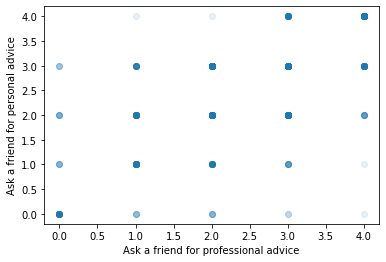

In [3]:
from matplotlib import pyplot as plt
plt.scatter(survey["q0007_0001"], survey["q0007_0002"], alpha=0.1)
plt.xlabel("Ask a friend for professional advice")
plt.ylabel("Ask a friend for personal advice")
plt.show()

In [4]:
from sklearn.cluster import KMeans

interest_columns = ["q0007_0001", "q0007_0002", "q0007_0003", "q0007_0004", "q0007_0005", "q0007_0008", "q0007_0009"]
rows_to_cluster = survey.dropna(subset=interest_columns)

classifier = KMeans(n_clusters=2)
classifier.fit(rows_to_cluster[interest_columns])
print(classifier.cluster_centers_)

[[2.84525547 2.81605839 2.84379562 2.39854015 0.6919708  3.07007299
  2.90218978]
 [1.88126649 1.8469657  0.85224274 1.72823219 0.57519789 2.64116095
  1.97097625]]


In [5]:
print(classifier.labels_)

[0 1 0 ... 1 1 1]


In [6]:
cluster_zero_indices = []
cluster_one_indices = []
for i in range(len(classifier.labels_)):
    if classifier.labels_[i] == 0:
        cluster_zero_indices.append(i)
    else:
        cluster_one_indices.append(i)
print(cluster_zero_indices)

[0, 2, 3, 5, 8, 11, 13, 15, 16, 20, 21, 22, 23, 25, 26, 27, 28, 30, 31, 32, 33, 34, 36, 37, 38, 40, 41, 43, 44, 45, 46, 47, 48, 50, 56, 59, 60, 61, 64, 67, 68, 69, 70, 71, 72, 73, 74, 76, 77, 80, 81, 83, 85, 91, 93, 96, 99, 100, 102, 103, 104, 105, 108, 110, 111, 112, 114, 115, 120, 121, 122, 124, 125, 126, 127, 133, 135, 136, 137, 138, 140, 141, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 173, 174, 177, 182, 183, 185, 186, 188, 190, 191, 192, 193, 194, 197, 200, 202, 203, 204, 205, 206, 207, 208, 210, 211, 213, 214, 215, 216, 217, 218, 219, 220, 221, 223, 224, 225, 226, 227, 228, 232, 234, 235, 238, 239, 242, 243, 244, 245, 246, 251, 252, 253, 254, 255, 257, 258, 259, 262, 265, 266, 267, 268, 269, 270, 271, 273, 274, 276, 277, 278, 279, 280, 282, 285, 287, 289, 290, 292, 293, 294, 295, 298, 302, 303, 304, 306, 307, 308, 309, 312, 313, 314, 315, 316, 317, 318, 319, 320, 321, 322, 323, 324, 326, 3

In [7]:
cluster_zero_df = rows_to_cluster.iloc[cluster_zero_indices]
cluster_one_df = rows_to_cluster.iloc[cluster_one_indices]

print(cluster_zero_df['educ4'].value_counts()/len(cluster_zero_df))
print(cluster_one_df['educ4'].value_counts()/len(cluster_one_df))

Post graduate degree    0.365889
College or more         0.330904
Some college            0.230321
High school or less     0.072886
Name: educ4, dtype: float64
Some college            0.314815
College or more         0.285714
Post graduate degree    0.251323
High school or less     0.145503
Name: educ4, dtype: float64
